# Uninformed (Blind) Search

The theory for this exercise lives in [README.md](./README.md) — state space, the evaluation
criteria, and the analysis of each algorithm. This notebook is only the code.

Everything below the setup is a stub for you to fill in, one algorithm at a time.

## Setup

In [1]:
from dataclasses import dataclass
from typing import Any
from collections import defaultdict

import heapq

import networkx as nx
import matplotlib.pyplot as plt

# Call clear_output(wait=True) before a redraw if you want the steps to
# animate in place instead of stacking up one figure per step.
from IPython.display import clear_output

## The graph

A `Node` carries its name, a heuristic (unused this week — it stays 0 until informed search) and
its current colour. `make_graph` takes the nodes and a dict of edges and builds an **undirected**
adjacency list: every edge you declare is added in both directions.

The order of the adjacency lists is the order you declared the edges in, and that order decides
which neighbour DFS visits first. Keep it in mind when your trace does not match the board.

In [2]:
@dataclass
class Node:
    value: Any = "no"
    heuristic: float = 0
    color: str = "white"


@dataclass
class Graph:
    nodes: Any
    edges: Any


def make_graph(nodes, edges):
    nodes = {v: Node(value=v, heuristic=h) for v, h in nodes}

    undirected_edges = defaultdict(list)
    for node, children in edges.items():
        for child, weight in children:
            undirected_edges[node].append((child, weight))
            undirected_edges[child].append((node, weight))

    return Graph(nodes=nodes, edges=undirected_edges)

## Drawing

`draw_spring_graph` lays the graph out with networkx and colours each node by `node.color`.
`display_graph(g, current)` is the one you call from inside an algorithm: it flashes `current` red
for the duration of the drawing, then restores its real colour.

In [3]:
def draw_spring_graph(graph, seed=1, figsize=(8, 8)):
    nodes = graph.nodes.values()
    edges = []
    for node, children in graph.edges.items():
        for c, weight in children:
            edges.append((node, c, weight))

    G = nx.Graph()
    for n in nodes:
        G.add_node(n.value)

    for f, t, _ in edges:
        G.add_edge(f, t)

    pos = nx.spring_layout(G, seed=seed)

    plt.figure(figsize=figsize)

    nx.draw_networkx_edges(G, pos, alpha=1, width=3)
    nx.draw_networkx_nodes(
        G,
        pos,
        nodelist=[n.value for n in nodes],
        node_size=1500,
        node_color=[n.color for n in nodes],
        edgecolors="black",
        linewidths=0.7,
    )
    nx.draw_networkx_labels(
        G,
        pos,
        labels={n.value: f"{n.value}({n.heuristic})" for n in nodes},
        font_size=10,
        font_color="black",
        font_weight="bold",
    )

    edge_labels = dict([((n1, n2), f"{w}") for n1, n2, w in edges])
    nx.draw_networkx_edge_labels(
        G, pos, edge_labels=edge_labels, label_pos=0.5, font_size=12
    )

    # Set margins for the axes so that nodes aren't clipped
    ax = plt.gca()
    ax.margins(0.1)
    plt.axis("off")
    plt.show()


def display_graph(g, current):
    old_color_curr = g.nodes[current].color
    g.nodes[current].color = "red"
    draw_spring_graph(g, seed=100, figsize=(12, 6))
    g.nodes[current].color = old_color_curr


def reset_colors(g):
    for _, node in g.nodes.items():
        node.color = "white"

## The example graph

Start `S`, goal `G`. Weighted, undirected. Small enough to trace by hand on the board, which is the
point — you should be able to predict every algorithm's answer before running it.

In [4]:
g = make_graph(
    nodes=[("A", 0), ("B", 0), ("C", 0), ("D", 0), ("S", 0), ("G", 0)],
    edges={
        "S": [("C", 14), ("B", 9), ("A", 7)],
        "A": [("B", 10), ("D", 15)],
        "B": [("C", 2), ("D", 11)],
        "C": [("G", 9)],
        "D": [("G", 6)],
    },
)

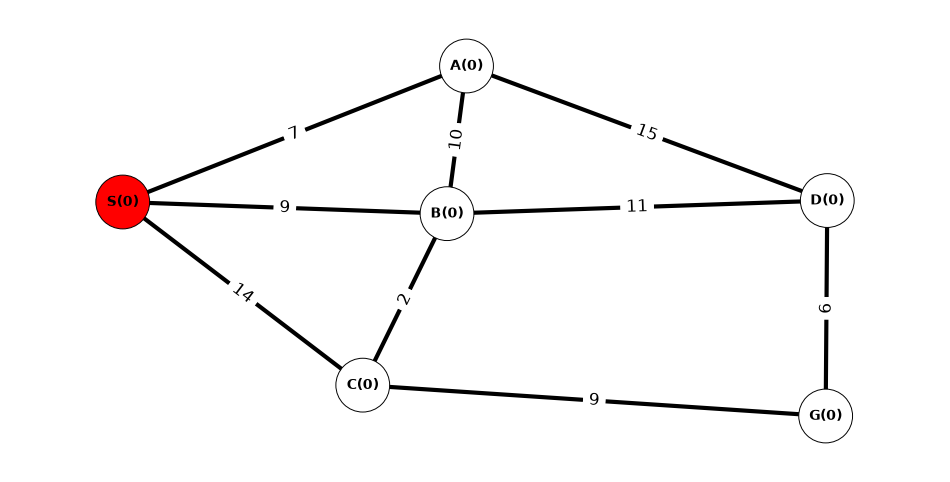

In [5]:
reset_colors(g)
display_graph(g, "S")

### Legend

`white` undiscovered &nbsp;·&nbsp; `gray` frontier &nbsp;·&nbsp; `red` currently expanding
&nbsp;·&nbsp; `blue` expanded &nbsp;·&nbsp; `green` goal

Every algorithm below should maintain these colours as it runs, and call `display_graph(g, current)`
once per expanded node. Call `reset_colors(g)` before each run.

## Depth-First Search — recursive

The call stack is your frontier.

In [6]:
def dfs_rec(g, curr, end):
    if curr == end:
        g.nodes[curr].color = 'blue'
        return True

    g.nodes[curr].color = 'gray'
    display_graph(g, curr)

    for node, _ in g.edges[curr]:
        if(g.nodes[node].color == 'white' and dfs_rec(g,node,end)):
            g.nodes[curr].color = 'blue'
            return True

    g.nodes[curr].color = 'blue'
    return False

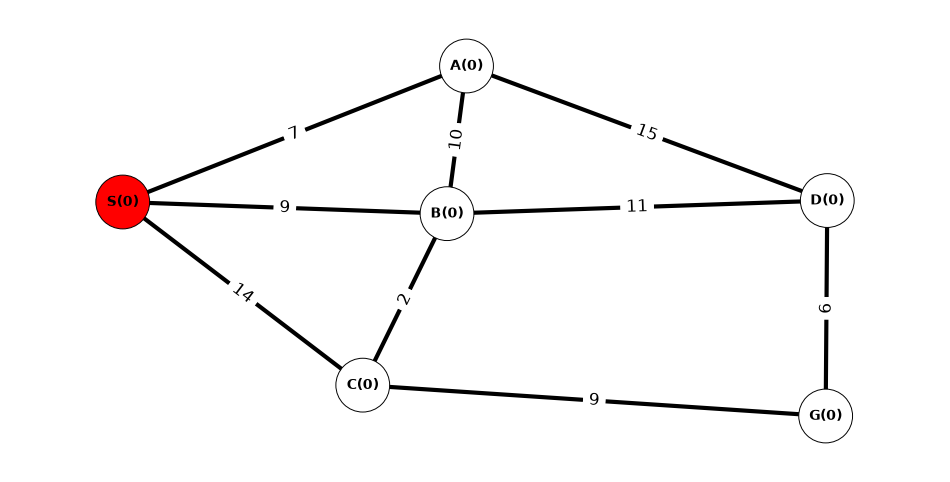

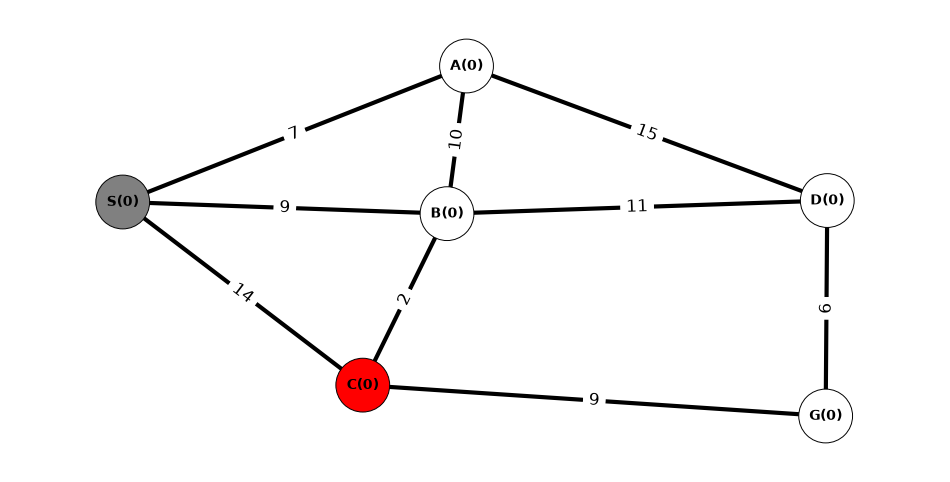

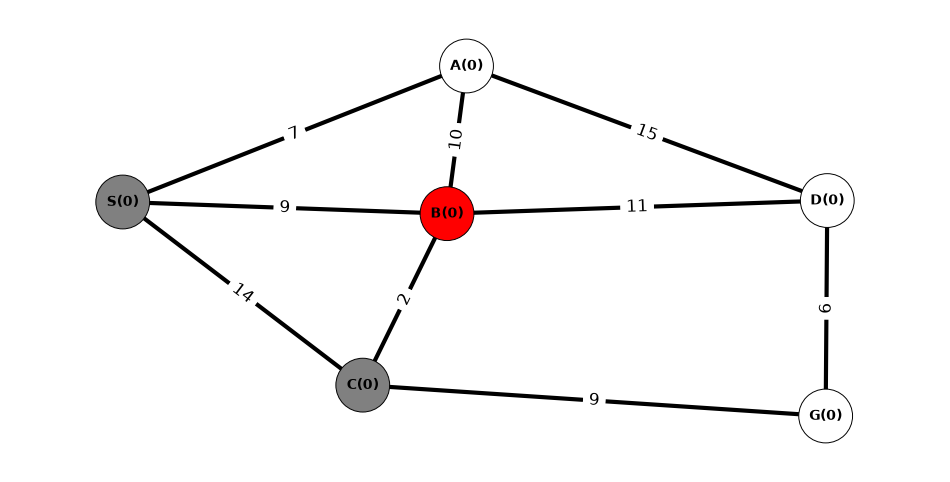

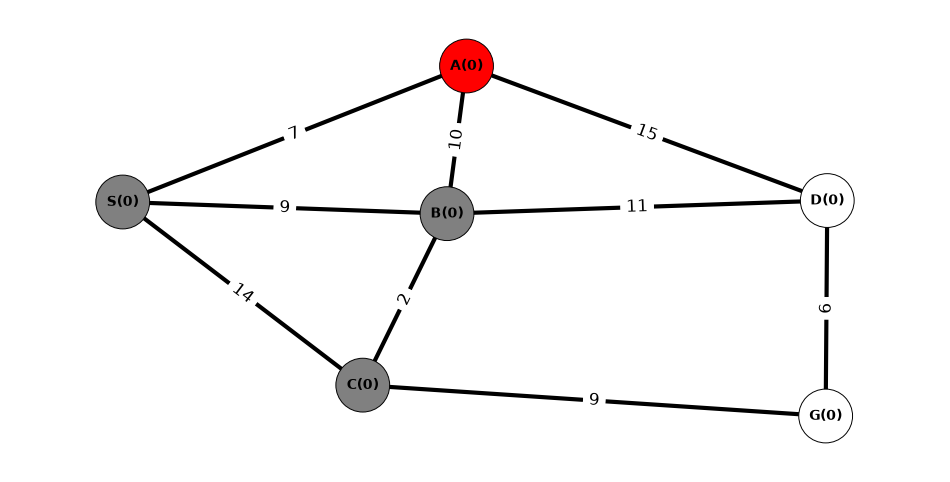

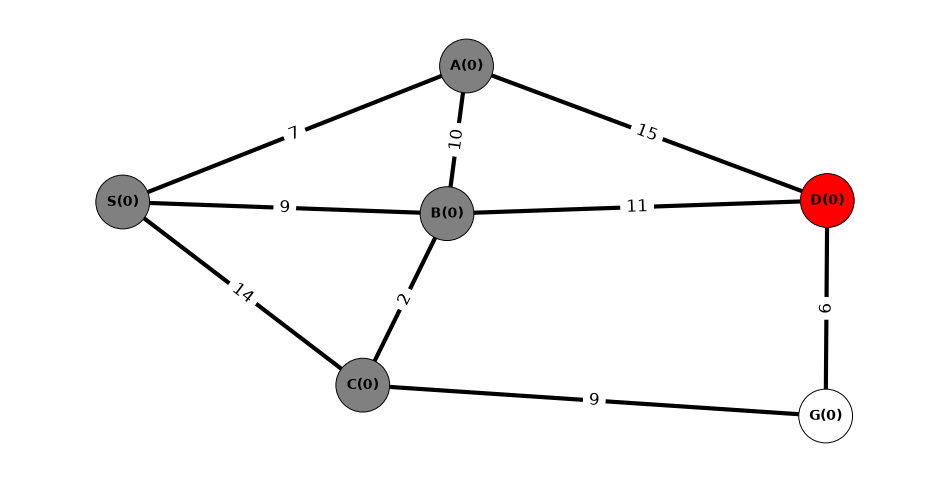

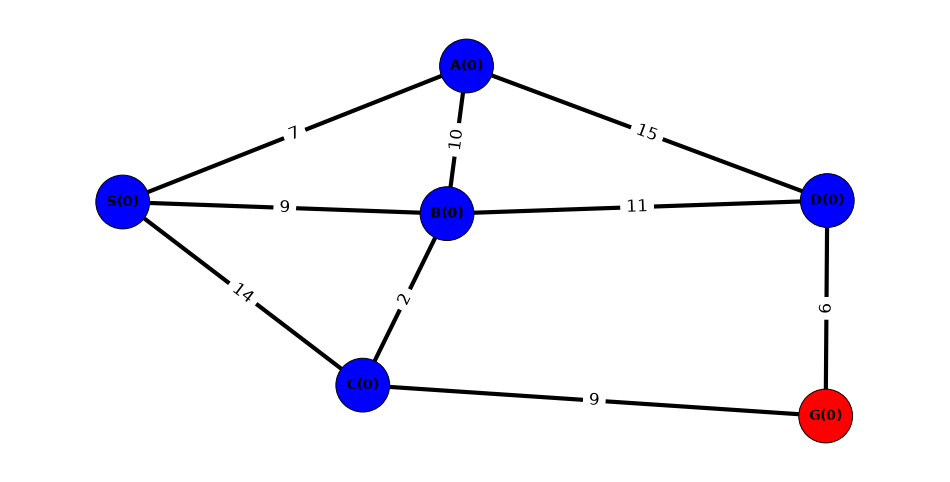

In [7]:
reset_colors(g)
dfs_rec(g, "S", "G")
display_graph(g, "G")

## Depth-First Search — iterative

The same traversal with an explicit stack. Compare the order it expands nodes in with the
recursive version — if they differ, look at the direction you push neighbours in.

In [8]:
def dfs(g, start, end):
    q = [start]
    while len(q) != 0:
        curr = q.pop()
        g.nodes[curr].color = 'blue'

        if curr == end:
            return True

        for node,_ in g.edges[curr]:
            if g.nodes[node].color =='white':
                q.append(node)
                g.nodes[node].color = "gray"

        display_graph(g, curr)


    display_graph(g, curr)
    return False


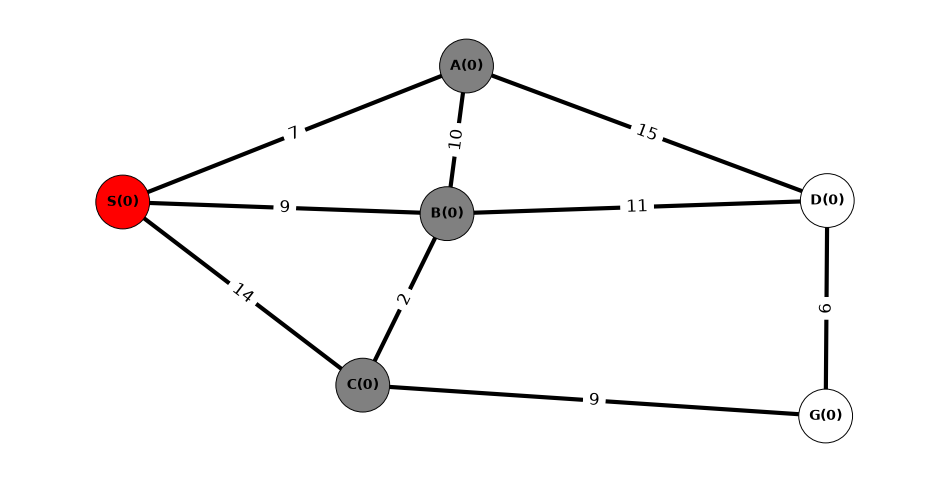

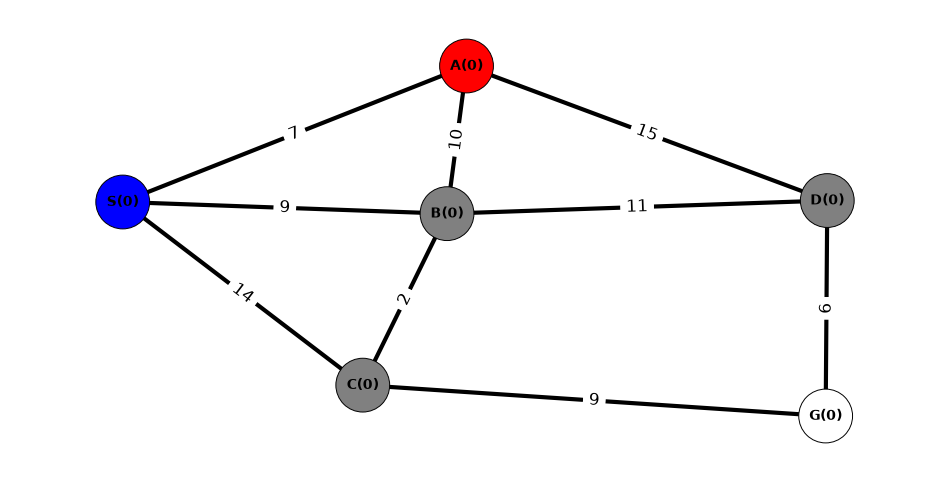

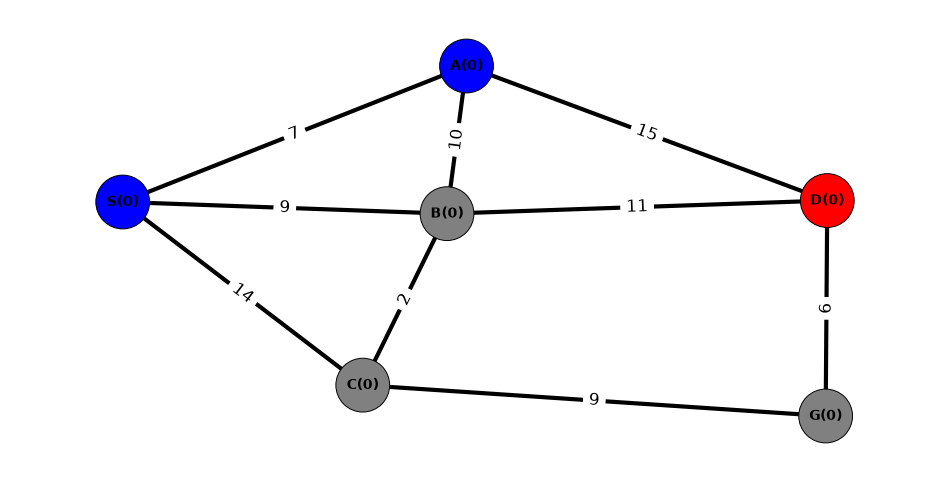

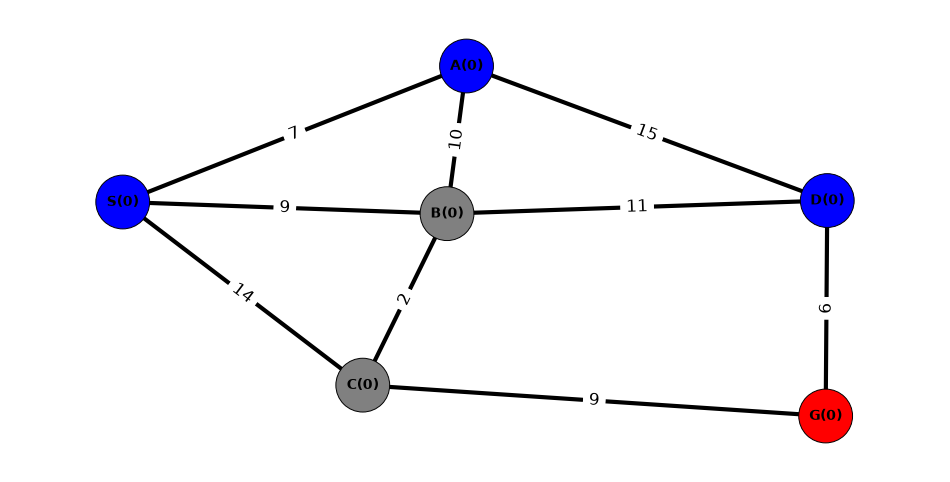

In [9]:
reset_colors(g)
dfs(g, "S", "G")
display_graph(g, "G")

## Breadth-First Search

Same code shape as iterative DFS, with one data structure swapped. That is the entire difference,
and it is worth seeing it that plainly.

In [10]:
def bfs(g, start, end):
    q = [start]
    while len(q) != 0:
        curr = q.pop(0)
        g.nodes[curr].color = 'blue'

        if curr == end:
            return True

        for node,_ in g.edges[curr]:
            if g.nodes[node].color =='white':
                q.append(node)
                g.nodes[node].color = "gray"

        display_graph(g, curr)


    display_graph(g, curr)
    return False

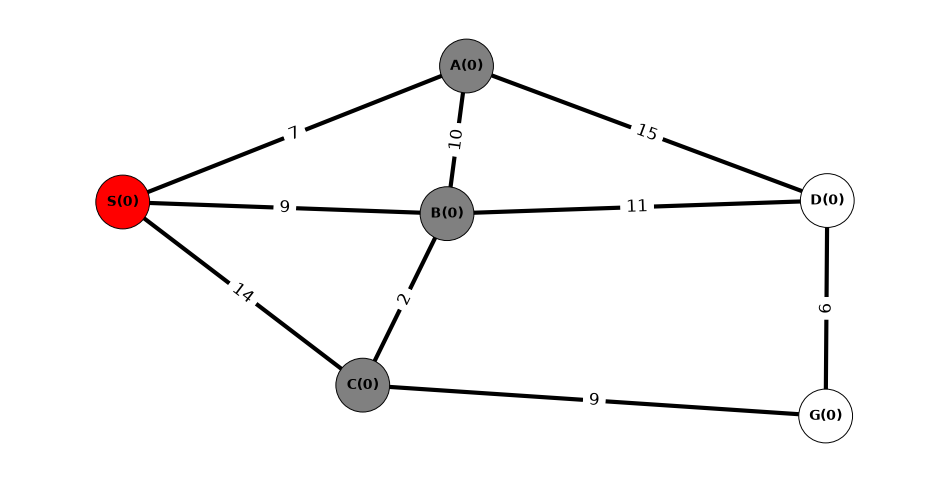

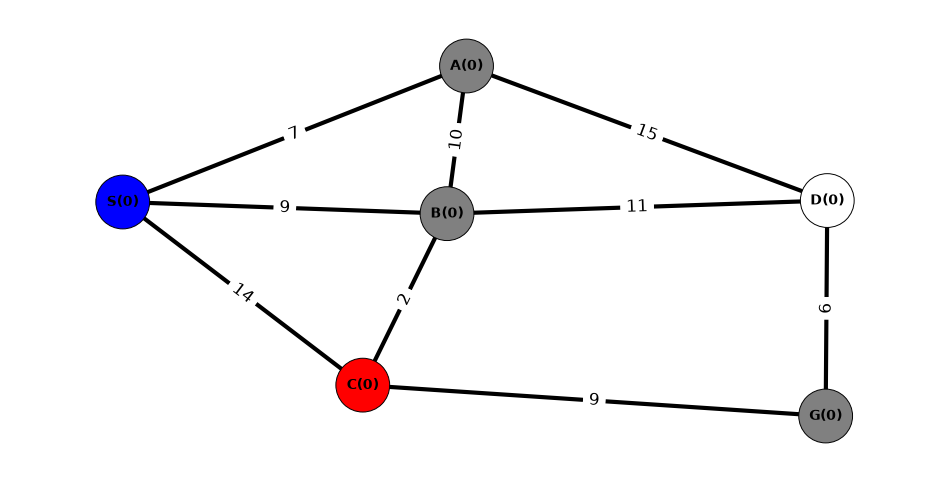

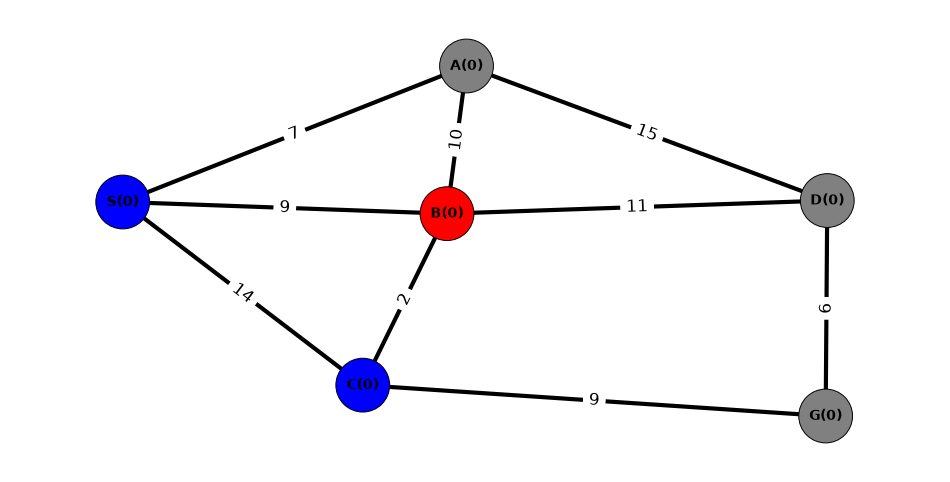

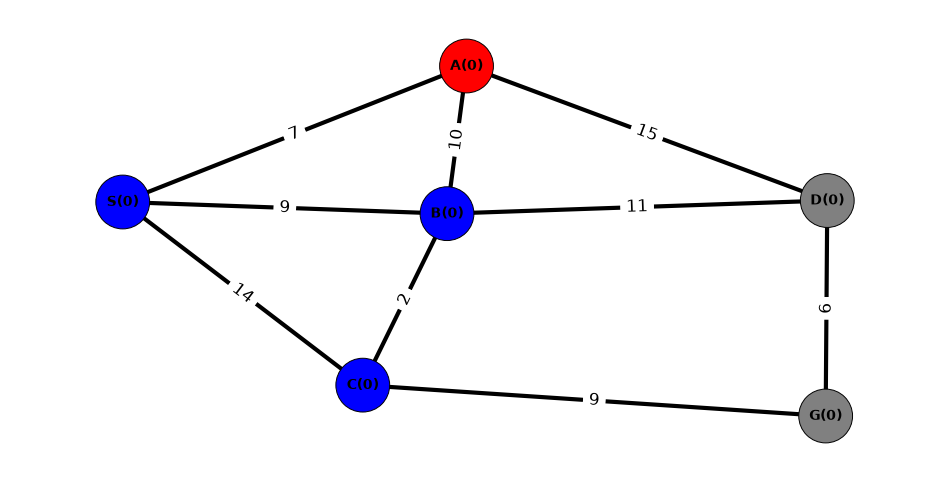

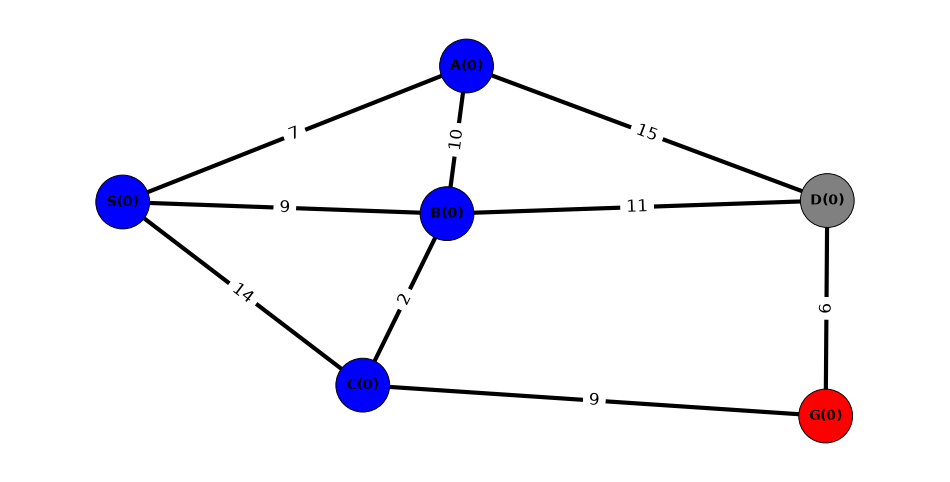

In [11]:
reset_colors(g)
bfs(g, "S", "G")
display_graph(g, "G")

## Depth-Limited Search

DFS that refuses to go deeper than `max_depth`. Note what happens when the limit is smaller than
the depth of the goal — it reports failure even though a solution exists.

In [12]:
def dls_rec(g, curr, end, max_depth):
    if curr == end:
        display_graph(g, curr)
        return True

    if max_depth <= 0:
        return False

    g.nodes[curr].color = 'gray'

    display_graph(g, curr)

    for node, _ in g.edges[curr]:
        if g.nodes[node].color == "white":
            g.nodes[node].color = "gray"
            if dls_rec(g, node, end, max_depth - 1):
                return True

    g.nodes[curr].color = 'blue'
    return False

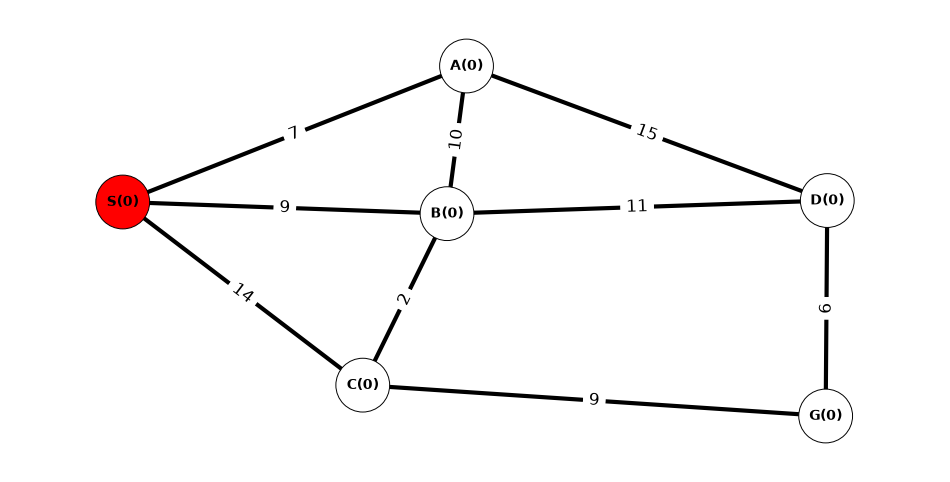

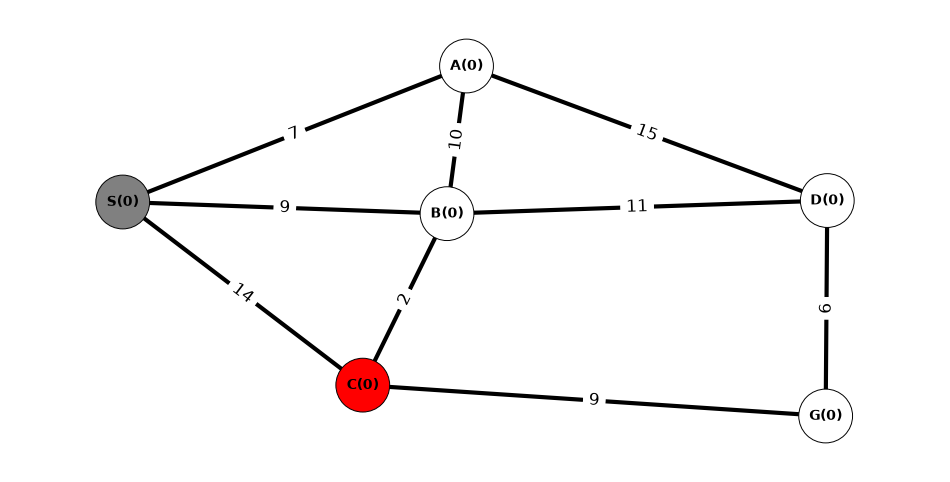

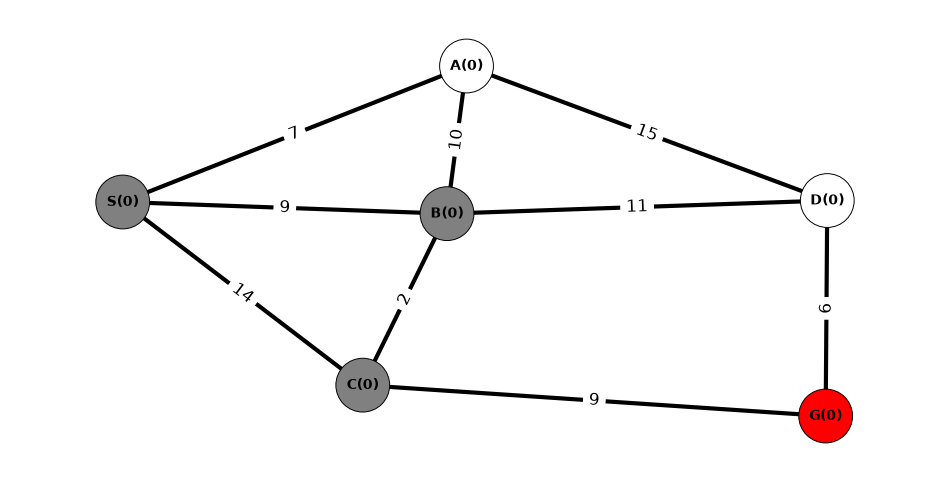

True

In [13]:
reset_colors(g)
dls_rec(g, "S", "G", 2)

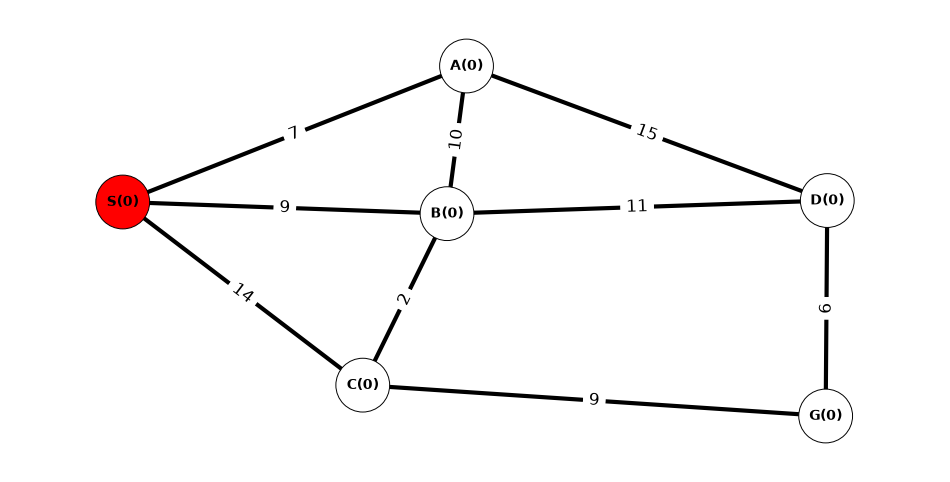

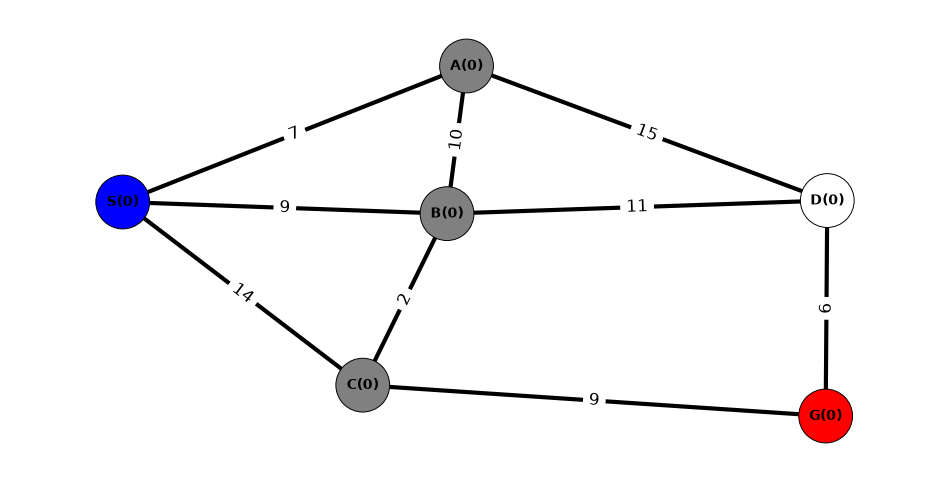

In [14]:
# A limit that is too small must fail, even though G is reachable
reset_colors(g)
dls_rec(g, "S", "G", 1)
display_graph(g, "G")

## Iterative Deepening Search

Call `dls` with limit 0, then 1, then 2, ... Remember to reset the colours between iterations —
each round is a fresh search.

In [15]:
def ids(g, start, end):
    i = 0
    while not dls_rec(g,start,end,i):
        i += 1
        reset_colors(g)
    print(i)

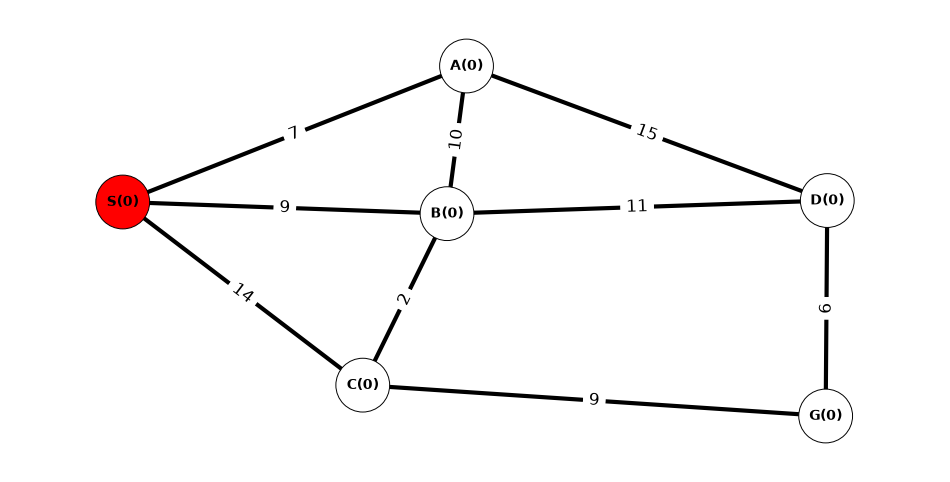

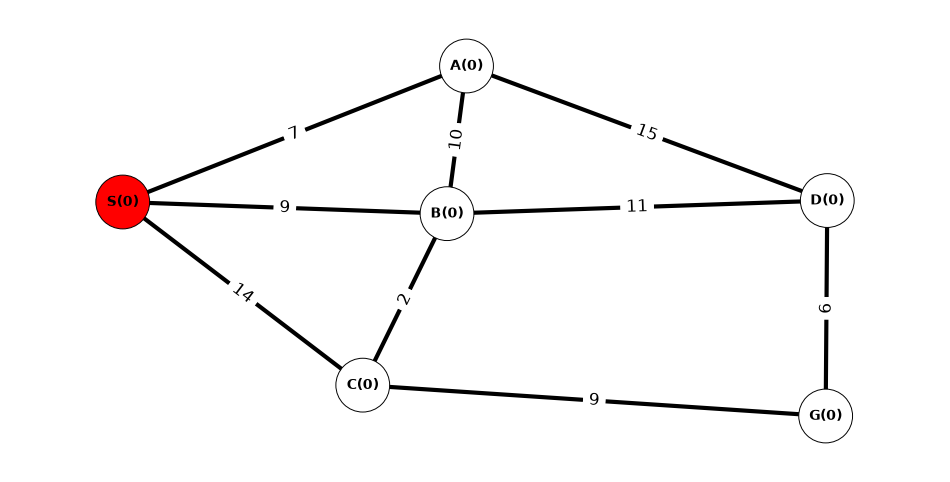

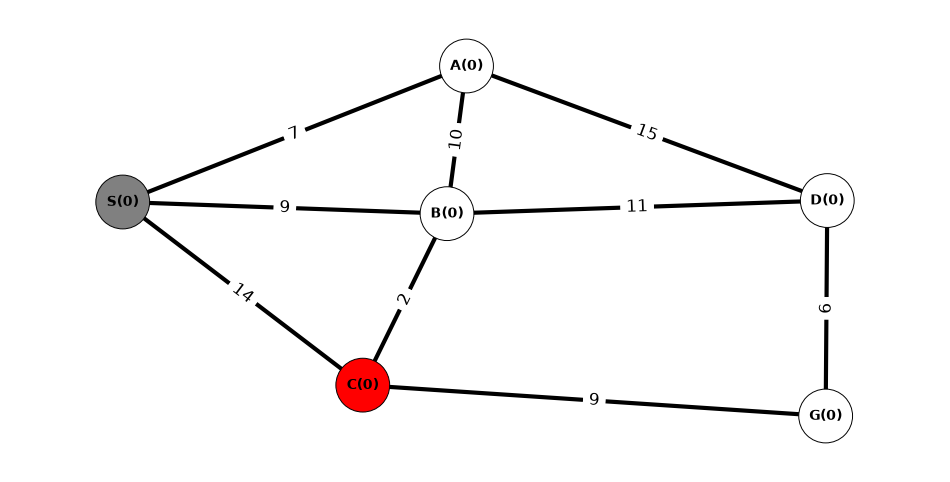

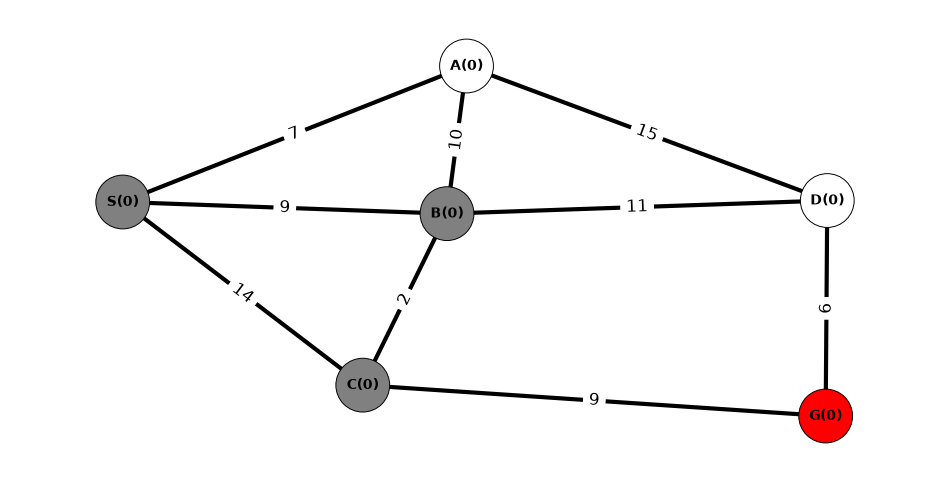

2


In [16]:
reset_colors(g)
ids(g, "S", "G")

## Uniform-Cost Search

The first algorithm here that uses the edge weights. Expand by lowest path cost `g(n)`, with a
priority queue — `heapq`, pushing `(cost, node)` tuples.

Predict the answer before you run it: BFS returns the path with the fewest edges, UCS returns the
cheapest one, and on this graph those are **not** the same path.

In [17]:
def relax(dist, x, y, w):
    if dist.get(y) == None or dist[y] > dist[x] + w:
        dist[y] = dist[x] + w

In [18]:
def ucs(g, start, end):
    priority_q = [(0,start)]
    dist = dict()
    dist[start] = 0

    while (len(priority_q) != 0):
        _, curr = heapq.heappop(priority_q)

        if (curr == end):
            break

        for node, w in g.edges[curr]:
            if g.nodes[node].color == 'white' or g.nodes[node].color == 'gray':
                relax(dist,curr,node,w)
                g.nodes[node].color = 'gray'
                heapq.heappush(priority_q, (dist[node], node))

        print(curr, dist, priority_q)
        display_graph(g, curr)
        g.nodes[curr].color = "blue"

    display_graph(g, curr)

S {'S': 0, 'C': 14, 'B': 9, 'A': 7} [(7, 'A'), (14, 'C'), (9, 'B')]


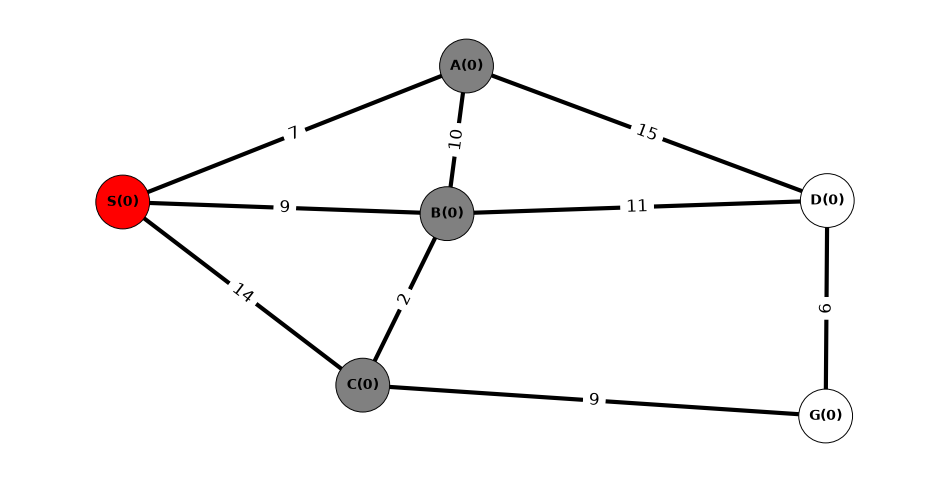

A {'S': 0, 'C': 14, 'B': 9, 'A': 7, 'D': 22} [(9, 'B'), (14, 'C'), (9, 'B'), (22, 'D')]


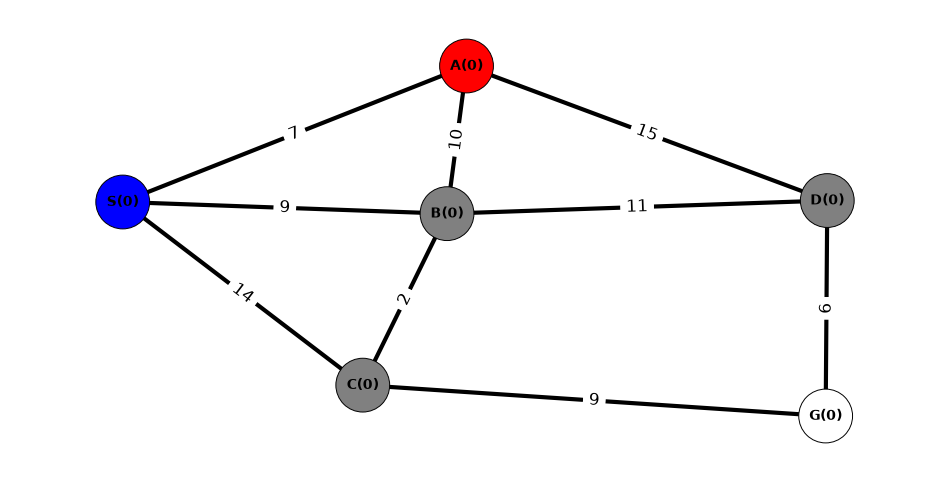

B {'S': 0, 'C': 11, 'B': 9, 'A': 7, 'D': 20} [(9, 'B'), (11, 'C'), (22, 'D'), (14, 'C'), (20, 'D')]


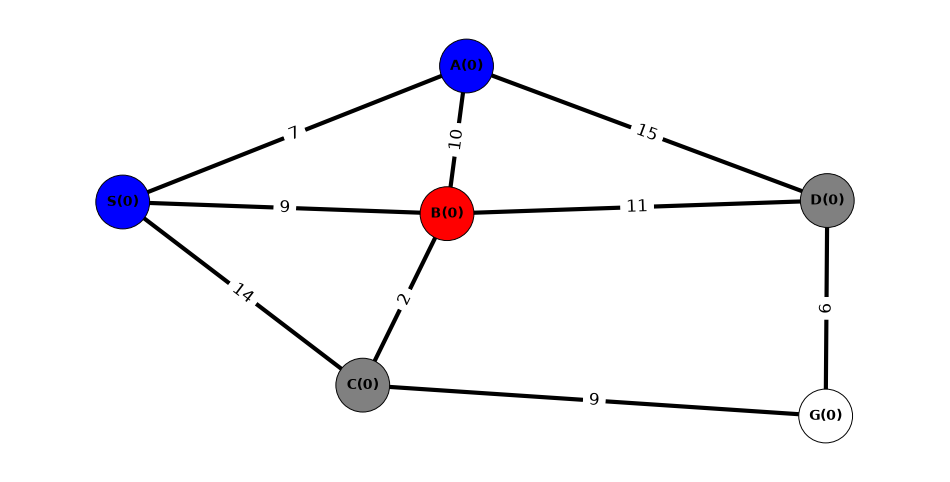

B {'S': 0, 'C': 11, 'B': 9, 'A': 7, 'D': 20} [(11, 'C'), (11, 'C'), (20, 'D'), (20, 'D'), (14, 'C'), (22, 'D')]


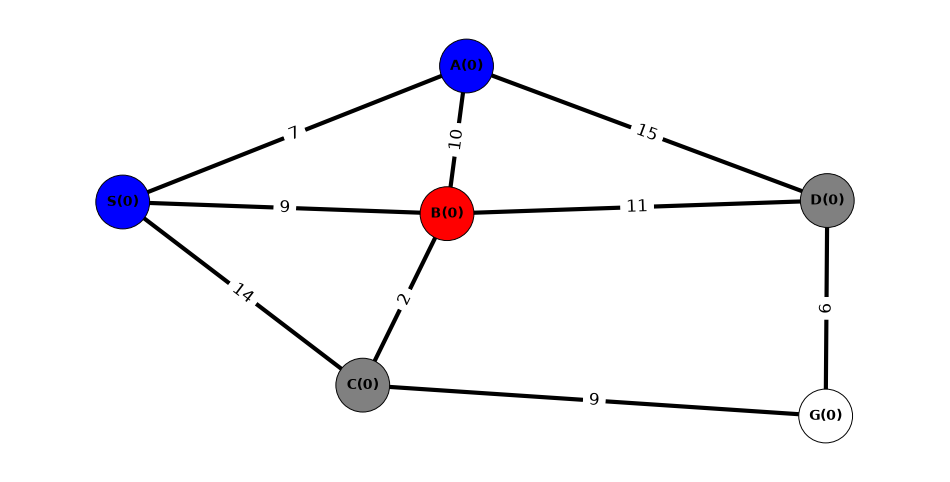

C {'S': 0, 'C': 11, 'B': 9, 'A': 7, 'D': 20, 'G': 20} [(11, 'C'), (14, 'C'), (20, 'D'), (20, 'D'), (22, 'D'), (20, 'G')]


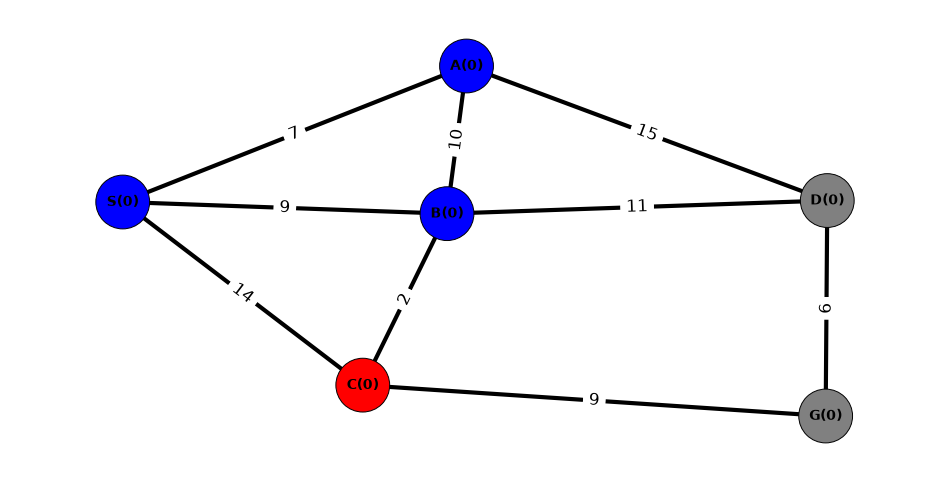

C {'S': 0, 'C': 11, 'B': 9, 'A': 7, 'D': 20, 'G': 20} [(14, 'C'), (20, 'D'), (20, 'D'), (20, 'G'), (22, 'D'), (20, 'G')]


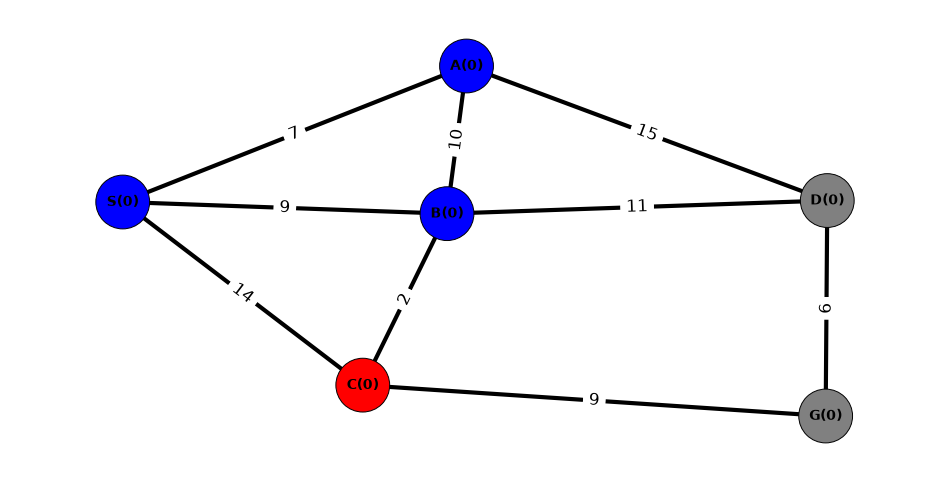

C {'S': 0, 'C': 11, 'B': 9, 'A': 7, 'D': 20, 'G': 20} [(20, 'D'), (20, 'D'), (20, 'G'), (20, 'G'), (22, 'D'), (20, 'G')]


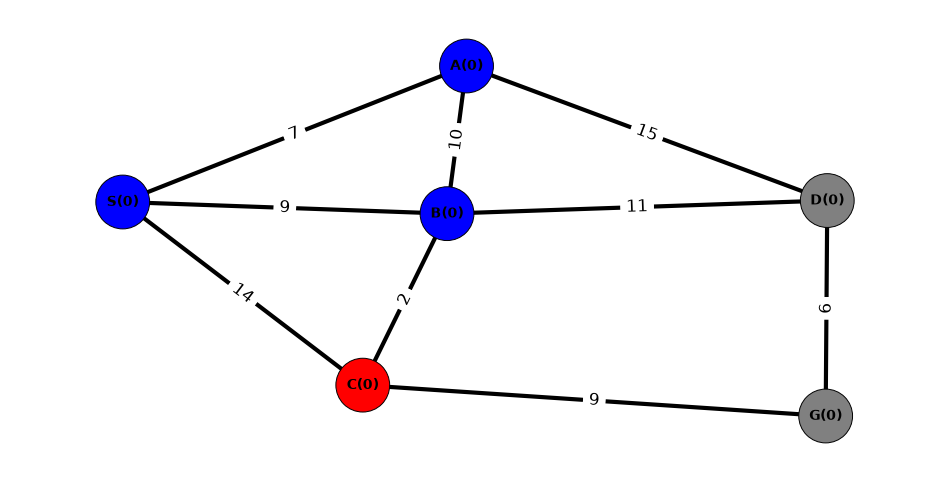

D {'S': 0, 'C': 11, 'B': 9, 'A': 7, 'D': 20, 'G': 20} [(20, 'D'), (20, 'G'), (20, 'G'), (20, 'G'), (22, 'D'), (20, 'G')]


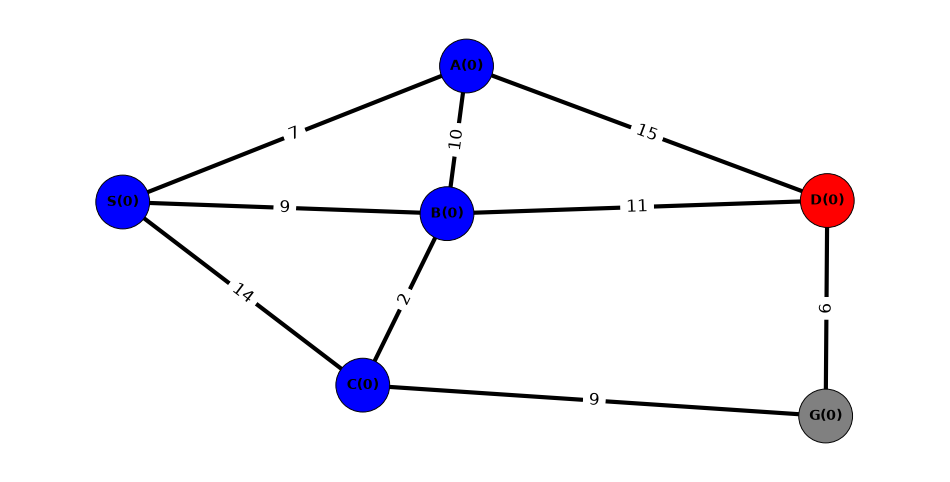

D {'S': 0, 'C': 11, 'B': 9, 'A': 7, 'D': 20, 'G': 20} [(20, 'G'), (20, 'G'), (20, 'G'), (20, 'G'), (22, 'D'), (20, 'G')]


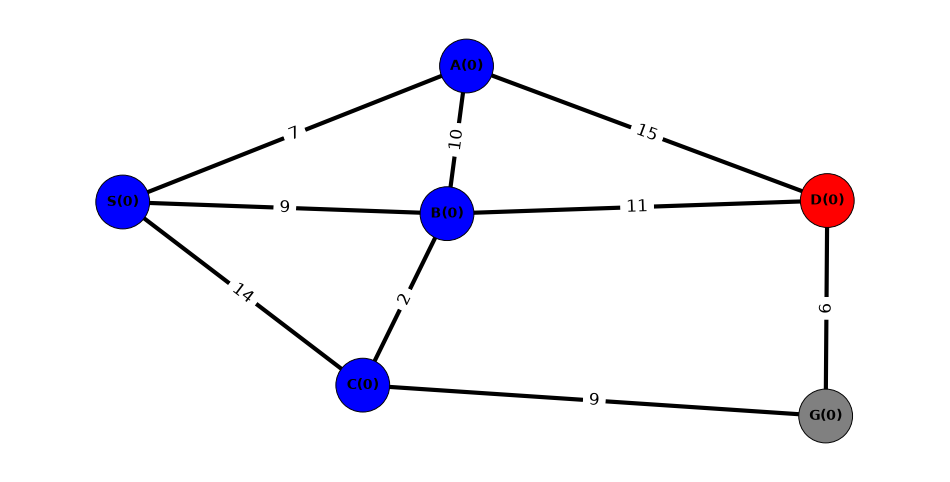

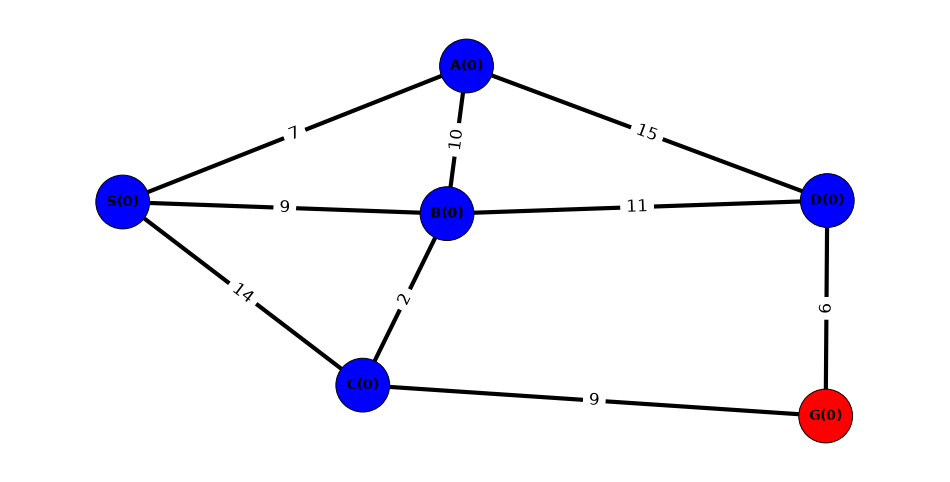

In [19]:
reset_colors(g)
ucs(g, "S", "G")

## Bidirectional Search

Two searches at once — one forward from `start`, one backward from `end` — expanded alternately
until they meet. Two trees of depth _d_/2 are much smaller than one of depth _d_: with
b = d = 10, b^(d/2) + b^(d/2) is roughly 50,000 times less than b^d.

Our graph is undirected, so the backward search can use the same adjacency lists. On a directed
graph you would first have to build the reversed edges.

**Use a second set of colours for the backward search**, otherwise the drawing is unreadable and
you lose the one thing worth seeing here — two wavefronts growing towards each other:

| direction | frontier | expanded |
|-----------|----------|----------|
| forward   | `gray`   | `blue`   |
| backward  | `orange` | `purple` |

and `green` for the node where they meet. Any matplotlib colour name works in `node.color`.

In [ ]:
def bidirectional_bfs(g, start, end):
    if start == end:
        g.nodes[start].color = "green"
        display_graph(g, start)
        return [start]

    parent_f, parent_b = {start: None}, {end: None}
    depth_f, depth_b = {start: 0}, {end: 0}
    frontier_f, frontier_b = [start], [end]

    g.nodes[start].color = "gray"
    g.nodes[end].color = "orange"

    def expand(frontier, parent, depth, frontier_color, done_color):
        nxt = []
        for curr in frontier:
            display_graph(g, curr)
            g.nodes[curr].color = done_color
            for node, _ in g.edges[curr]:
                if node in parent:
                    continue
                parent[node] = curr
                depth[node] = depth[curr] + 1
                g.nodes[node].color = frontier_color
                nxt.append(node)
        return nxt

    def join(meet):
        left, node = [], meet
        while node is not None:
            left.append(node)
            node = parent_f[node]
        left.reverse()

        right, node = [], parent_b[meet]
        while node is not None:
            right.append(node)
            node = parent_b[node]

        return left + right

    while frontier_f and frontier_b:
        if len(frontier_f) <= len(frontier_b):
            frontier_f = expand(frontier_f, parent_f, depth_f, "gray", "blue")
        else:
            frontier_b = expand(frontier_b, parent_b, depth_b, "orange", "purple")

        # Both searches may have reached several nodes in common. Take the one
        # giving the shortest combined path -- the first one touched need not be
        # the best, because the two sides are not always at the same depth.
        common = set(depth_f) & set(depth_b)
        if common:
            meet = min(common, key=lambda n: depth_f[n] + depth_b[n])
            g.nodes[meet].color = "green"
            display_graph(g, meet)
            return join(meet)

    return None

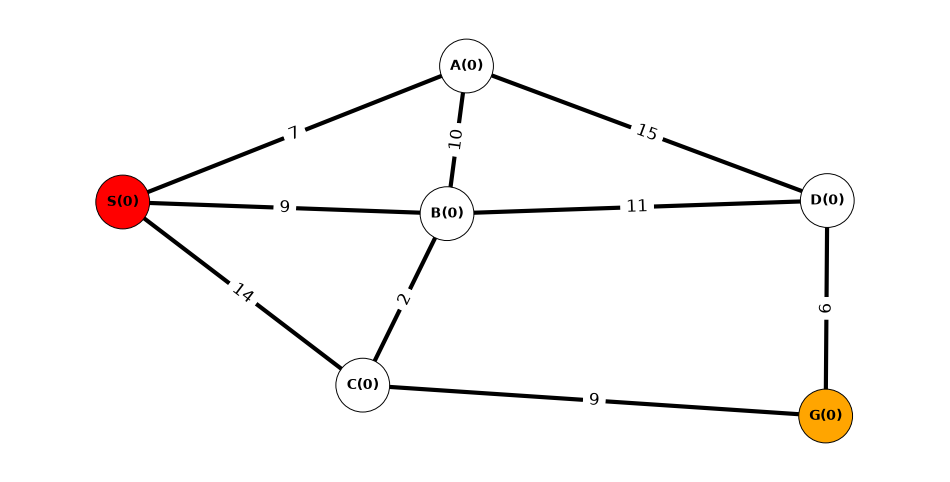

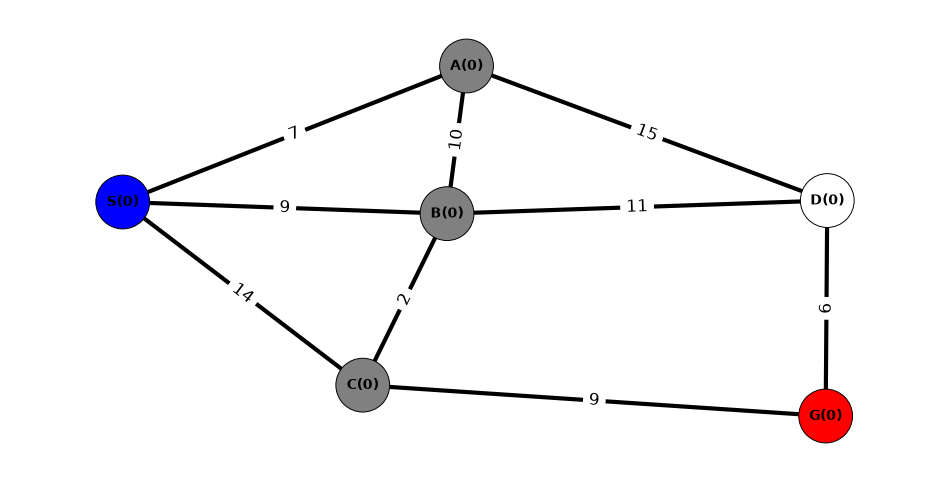

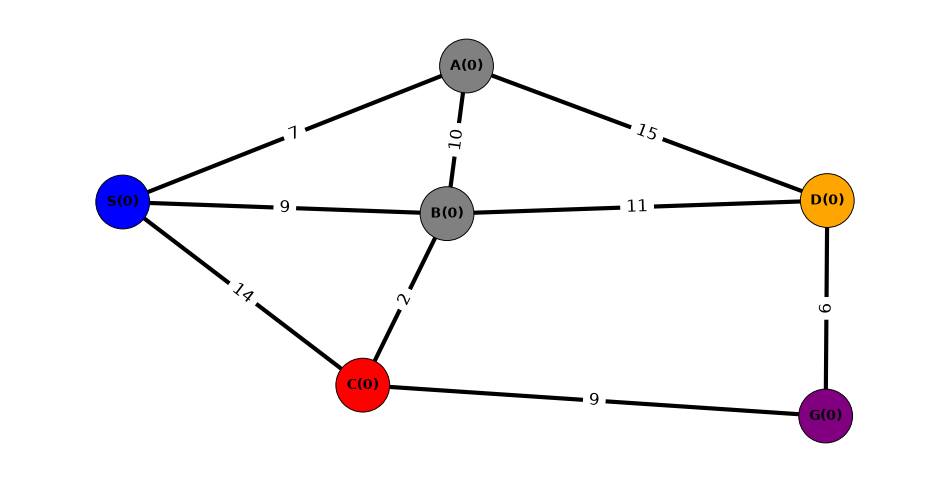

['S', 'C', 'G']


In [60]:
reset_colors(g)
path = bidirectional_bfs(g, "S", "G")
print(path)

Once it runs, compare it with plain `bfs` on the same graph. Both should return a path with the
same number of edges, but count how many nodes each one expanded before finding it — that
difference is the whole argument for bidirectional search, and on a graph this small it will be
modest. It is worth predicting how the gap grows with depth.